In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


plt.rcParams['font.family'] = 'Times New Roman,Microsoft YaHei'
plt.rcParams['mathtext.fontset'] = 'stix'  # 设置数学公式字体为stix
from sklearn import preprocessing
import numpy as np
from matplotlib.lines import Line2D

from matplotlib.patheffects import withStroke

In [2]:
dfmusic = pd.read_pickle("df_chordkey,pkl")
dfbird = pd.read_pickle('final_birds_df.pkl')
dfbasic = pd.read_pickle("soundfeature_other.pkl")
# 去除重复列
dfbasic = dfbasic.loc[:, ~dfbasic.columns.duplicated()]


# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"


# 替换 level 列的值
dfbasic['level'] = dfbasic.apply(replace_level, axis=1)
df = pd.merge(dfmusic, dfbird, on=['Date', 'place', 'level'], how='inner')
df = pd.merge(df, dfbasic, on=['Date', 'place', 'level'], how='inner')
# 栖息地分类映射
habitat_mapping = {
    'Aquatic and Wetland Surface Birds': ['Eurasian Wigeon', 'Tundra Swan', 'Mallard',
                                          'Greater White-fronted Goose', 'Common Goldeneye',
                                          'Green-winged Teal', 'Eurasian Coot', 'Eurasian Moorhen'],

    'Shoreline and Marsh Birds': ['Eurasian Curlew', 'Whimbrel'],

    'Grassland Ground Birds': ['Olive-backed Pipit', 'Yellow-browed Bunting', 'Yellow-billed Grosbeak'],

    'Shrub Layer Birds': ['Light-vented Bulbul', 'Chinese Hwamei', 'Japanese Tit',
                          'Silver-throated Tit', 'Chinese Blackbird', 'Pale-legged Leaf Warbler'],

    'Lower Canopy Birds': ['Pale Thrush', 'Oriental Magpie'],

    'Upper Canopy and Aerial Birds': ["Swinhoe's White-eye"]
}

# 将所有物种映射到栖息地类别
species_to_habitat = {}
for habitat, species_list in habitat_mapping.items():
    for species in species_list:
        species_to_habitat[species] = habitat


# 分类函数
def classify_bird_habitat(species):
    return species_to_habitat.get(species, 'Other')  # 若未匹配到则归类为 'Other'


# 应用分类函数
df['habitat'] = df['bird'].copy().apply(classify_bird_habitat)

# 根据分类映射顺序创建分类类型
habitat_order = list(habitat_mapping.keys())
df['habitat'] = pd.Categorical(df['habitat'], categories=habitat_order, ordered=True)
# 定义和弦质量的映射
chord_quality_map = {
    'maj': '',  # major 不需要后缀
    'min': 'm',  # minor 转换为 'm'
    'dim': 'dim',  # diminished 保持不变
    'aug': 'aug',  # augmented 保持不变
    '7': '7',  # dominant 7th
    'maj7': 'maj7',  # major 7th
    'min7': 'm7',  # minor 7th
    'dim7': 'dim7',  # diminished 7th
    'sus4': 'sus4',  # suspended 4th
    'sus2': 'sus2'  # suspended 2nd
}


def convert_chord_name(chord_name):
    if ':' in chord_name:
        root, quality = chord_name.split(':')
        # 使用映射字典转换和弦质量
        return f"{root}{chord_quality_map.get(quality, '')}"
    else:
        return chord_name


# 应用转换函数
df['event'] = df['event'].apply(convert_chord_name)


In [3]:
# 定义 S 型隶属函数
def sigmoid_membership(x, x0, k=10):
    return 1 / (1 + np.exp(-k * (x - x0)))
def triangular_membership(x, a, b, c):
    if x < a or x > c:
        return 0
    elif a <= x <= b:
        return (x - a) / (b - a)
    elif b < x <= c:
        return (c - x) / (c - b)
def trapezoidal_membership(x, a, b, c, d):
    if x < a or x > d:
        return 0
    elif a <= x < b:
        return (x - a) / (b - a)
    elif b <= x <= c:
        return 1
    elif c < x <= d:
        return (d - x) / (d - c)
def gaussian_membership(x, c, sigma):
    return np.exp(-((x - c) ** 2) / (2 * sigma ** 2))

def z_shape_membership(x, a, b):
    if x <= a:
        return 1
    elif a < x <= (a + b) / 2:
        return 1 - 2 * ((x - a) / (b - a)) ** 2
    elif (a + b) / 2 < x < b:
        return 2 * ((x - b) / (b - a)) ** 2
    else:
        return 0

In [4]:
# 选择 "event" 和 "LEQf" 列
dfsort = df[["event", "LEQf"]]
# 按 "event" 分组并计算 "LEQf" 的平均值
dfsort = dfsort.groupby("event", as_index=False).mean()
# 按 "LEQf" 从大到小排序
dfsort = dfsort.sort_values(by="LEQf", ascending=False)
# 按和弦类型排序（大三和弦在前，小三和弦在后）
dfsort["type"] = ["major" if not event.endswith("m") else "minor" for event in dfsort["event"]]
dfsort = dfsort.sort_values(by=["type", "LEQf"], ascending=[True, False])
# 选择 "event" 和 "LEQf" 列
dfsort = df[["event", "LEQf"]]
# 按 "event" 分组并计算 "LEQf" 的平均值
dfsort = dfsort.groupby("event", as_index=False).mean()
# 按 "LEQf" 从大到小排序
dfsort = dfsort.sort_values(by="LEQf", ascending=False)
dfsort["LEQf"].mean()
# 假设 df 是用户的数据
df["LEQf"] = pd.to_numeric(df["LEQf"], errors="coerce")  # 确保 LEQf 是数值类型
df = df.dropna(subset=["LEQf"])  # 删除无法转换的行

# 计算 event 的平均 LEQf 值
dfsort = df.groupby("event", as_index=False)["LEQf"].mean()

# 使用 TOPSIS 进行排序
dfsort["LEQf_norm"] = (dfsort["LEQf"] - dfsort["LEQf"].min()) / (dfsort["LEQf"].max() - dfsort["LEQf"].min())

# 计算正理想解（最大值）和负理想解（最小值）
ideal_best = dfsort["LEQf_norm"].max()
ideal_worst = dfsort["LEQf_norm"].min()

# 计算每个 event 到理想解的距离
dfsort["D_best"] = np.sqrt((dfsort["LEQf_norm"] - ideal_best) ** 2)
dfsort["D_worst"] = np.sqrt((dfsort["LEQf_norm"] - ideal_worst) ** 2)

# 计算 TOPSIS 分数
dfsort["TOPSIS_score"] = dfsort["D_worst"] / (dfsort["D_best"] + dfsort["D_worst"])

# 按 TOPSIS 分数排序
dfsort = dfsort.sort_values(by="TOPSIS_score", ascending=False)

# 根据 TOPSIS 分数划分为高低类别（前50%为高，后50%为低）
median_score = dfsort["TOPSIS_score"].median()
dfsort["category"] = np.where(dfsort["TOPSIS_score"] >= median_score, "High", "Low")

In [5]:
dfsort

,event,LEQf,LEQf_norm,D_best,D_worst,TOPSIS_score,category
4,B,77.434683,1.000000,0.000000,1.000000,1.000000,High
8,C#m,76.813743,0.918753,0.081247,0.918753,0.918753,High
14,E,76.783190,0.914755,0.085245,0.914755,0.914755,High
12,D#m,76.673525,0.900406,0.099594,0.900406,0.900406,High
11,D#,76.312698,0.853193,0.146807,0.853193,0.853193,High
2,A#m,76.143282,0.831026,0.168974,0.831026,0.831026,High
0,A,76.091611,0.824265,0.175735,0.824265,0.824265,High
22,G#m,76.054602,0.819423,0.180577,0.819423,0.819423,High
7,C#,75.647065,0.766098,0.233902,0.766098,0.766098,High
3,Am,75.575452,0.756728,0.243272,0.756728,0.756728,High


In [6]:

# 计算中位数作为 x0
x0 = dfsort["TOPSIS_score"].median()

# 计算隶属度
dfsort["membership"] = dfsort["TOPSIS_score"].apply(lambda x: sigmoid_membership(x, x0))

# 设定分类规则
dfsort["category"] = np.where(
    dfsort["membership"] > 0.7, "High",
    np.where(dfsort["membership"] < 0.3, "Low", "Both")
)

In [7]:
# 选择 "event" 和 "LEQf" 列
dfsort = df[["event", "LEQf"]]
# 按 "event" 分组并计算 "LEQf" 的平均值
dfsort = dfsort.groupby("event", as_index=False).mean()
# 按 "LEQf" 从大到小排序
dfsort = dfsort.sort_values(by="LEQf", ascending=False)
# 按和弦类型排序（大三和弦在前，小三和弦在后）
dfsort["type"] = ["major" if not event.endswith("m") else "minor" for event in dfsort["event"]]
dfsort = dfsort.sort_values(by="LEQf", ascending=True)
# 选择 "event" 和 "LEQf" 列
dfsort = df[["event", "LEQf"]]
# 按 "event" 分组并计算 "LEQf" 的平均值
dfsort = dfsort.groupby("event", as_index=False).mean()
# 按 "LEQf" 从大到小排序
dfsort = dfsort.sort_values(by="LEQf", ascending=False)
dfsort["LEQf"].mean()

# 使用 TOPSIS 进行排序
dfsort["LEQf_norm"] = (dfsort["LEQf"] - dfsort["LEQf"].min()) / (dfsort["LEQf"].max() - dfsort["LEQf"].min())

# 计算正理想解（最大值）和负理想解（最小值）
ideal_best = dfsort["LEQf_norm"].max()
ideal_worst = dfsort["LEQf_norm"].min()

# 计算每个 event 到理想解的距离
dfsort["D_best"] = np.sqrt((dfsort["LEQf_norm"] - ideal_best) ** 2)
dfsort["D_worst"] = np.sqrt((dfsort["LEQf_norm"] - ideal_worst) ** 2)

# 计算 TOPSIS 分数
dfsort["TOPSIS_score"] = dfsort["D_worst"] / (dfsort["D_best"] + dfsort["D_worst"])

# 按 TOPSIS 分数排序
dfsort = dfsort.sort_values(by="TOPSIS_score", ascending=False)

# 根据 TOPSIS 分数划分为高低类别（前50%为高，后50%为低）
median_score = dfsort["TOPSIS_score"].median()
dfsort["category"] = np.where(dfsort["TOPSIS_score"] >= median_score, "High", "Low")

In [8]:
# 计算中位数作为 x0
x0 = dfsort["TOPSIS_score"].median()


dfsort["membership"] = dfsort["TOPSIS_score"].apply(lambda x: sigmoid_membership(x, x0))

# 设定分类规则
dfsort["category"] = np.where(
    dfsort["membership"] > 0.7, "High",
    np.where(dfsort["membership"] < 0.3, "Low", "Both")
)

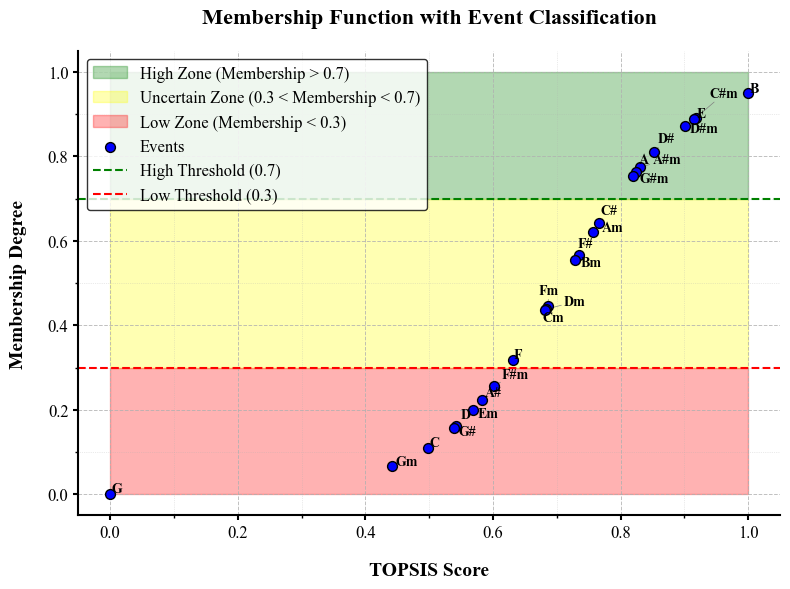

In [9]:
from matplotlib.ticker import AutoMinorLocator
from adjustText import adjust_text

# 绘图
fig, ax = plt.subplots(figsize=(8, 6))  # 图形尺寸

# 填充区间颜色
ax.fill_between(
    dfsort["TOPSIS_score"], 0.7, 1,
    color='green', alpha=0.3, label='High Zone (Membership > 0.7)'
)
ax.fill_between(
    dfsort["TOPSIS_score"], 0.3, 0.7,
    color='yellow', alpha=0.3, label='Uncertain Zone (0.3 < Membership < 0.7)'
)
ax.fill_between(
    dfsort["TOPSIS_score"], 0, 0.3,
    color='red', alpha=0.3, label='Low Zone (Membership < 0.3)'
)

# 散点图
scatter = ax.scatter(
    dfsort["TOPSIS_score"], dfsort["membership"],
    c='blue', s=50, edgecolor='black', zorder=3, label='Events'
)

# 添加事件标注，自动调整位置
texts = [
    ax.text(
        row["TOPSIS_score"], row["membership"], row["event"],
        fontsize=10, weight='bold', color='black'
    ) for _, row in dfsort.iterrows()
]
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# 绘制阈值线
ax.axhline(y=0.7, color='green', linestyle='--', linewidth=1.5, label='High Threshold (0.7)', zorder=2)
ax.axhline(y=0.3, color='red', linestyle='--', linewidth=1.5, label='Low Threshold (0.3)', zorder=2)

# 设置标题和标签
ax.set_title('Membership Function with Event Classification', fontsize=16, weight='bold', pad=20)
ax.set_xlabel('TOPSIS Score', fontsize=14, weight='bold', labelpad=15)
ax.set_ylabel('Membership Degree', fontsize=14, weight='bold', labelpad=15)

# 设置坐标轴刻度加粗
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)
ax.tick_params(axis='both', which='minor', labelsize=10, width=1.0)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# 设置图例
ax.legend(fontsize=12, loc='upper left', frameon=True, edgecolor='black')

# 添加网格
ax.grid(visible=True, which='major', linestyle='--', linewidth=0.7, alpha=0.8)
ax.grid(visible=True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

# 去除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调整边框线宽
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# 调整布局
plt.tight_layout()
plt.show()

In [10]:
# 选择 "event" 和 "LEQf" 列
dfsort = df[["event", "LEQf"]].copy()
# 按和弦类型排序（大三和弦在前，小三和弦在后）
dfsort["event"] = [event if not event.endswith("m") else event[:-1] for event in dfsort["event"]]
dfsort=dfsort.groupby("event", as_index=False).mean()
# 按 "LEQf" 从大到小排序
dfsort = dfsort.sort_values(by="LEQf", ascending=False)

dfsort = dfsort.sort_values(by="LEQf", ascending=True)
# 按 "event" 分组并计算 "LEQf" 的平均值
dfsort = dfsort.groupby("event", as_index=False).mean()
# 按 "LEQf" 从大到小排序
dfsort = dfsort.sort_values(by="LEQf", ascending=False)
dfsort["LEQf"].mean()
# 使用 TOPSIS 进行排序
dfsort["LEQf_norm"] = (dfsort["LEQf"] - dfsort["LEQf"].min()) / (dfsort["LEQf"].max() - dfsort["LEQf"].min())

# 计算正理想解（最大值）和负理想解（最小值）
ideal_best = dfsort["LEQf_norm"].max()
ideal_worst = dfsort["LEQf_norm"].min()

# 计算每个 event 到理想解的距离
dfsort["D_best"] = np.sqrt((dfsort["LEQf_norm"] - ideal_best) ** 2)
dfsort["D_worst"] = np.sqrt((dfsort["LEQf_norm"] - ideal_worst) ** 2)

# 计算 TOPSIS 分数
dfsort["TOPSIS_score"] = dfsort["D_worst"] / (dfsort["D_best"] + dfsort["D_worst"])

# 按 TOPSIS 分数排序
dfsort = dfsort.sort_values(by="TOPSIS_score", ascending=False)

# 根据 TOPSIS 分数划分为高低类别（前50%为高，后50%为低）
median_score = dfsort["TOPSIS_score"].median()
dfsort["category"] = np.where(dfsort["TOPSIS_score"] >= median_score, "High", "Low")

In [11]:
# 计算中位数作为 x0
x0 = dfsort["TOPSIS_score"].mean()

# 计算隶属度
dfsort["membership"] = dfsort["TOPSIS_score"].apply(lambda x: sigmoid_membership(x, x0))

# 设定分类规则
dfsort["category"] = np.where(
    dfsort["membership"] > 0.7, "High",
    np.where(dfsort["membership"] < 0.3, "Low", "Both")
)
dfsort

,event,LEQf,LEQf_norm,D_best,D_worst,TOPSIS_score,category,membership
2,B,76.333587,1.000000,0.000000,1.000000,1.000000,High,0.922733
6,D#,76.315869,0.997176,0.002824,0.997176,0.997176,High,0.920696
7,E,76.292244,0.993412,0.006588,0.993412,0.993412,High,0.917903
0,A,76.066168,0.957384,0.042616,0.957384,0.957384,High,0.886342
4,C#,75.741661,0.905670,0.094330,0.905670,0.905670,High,0.822995
9,F#,75.159163,0.812842,0.187158,0.812842,0.812842,Both,0.647597
8,F,74.661567,0.733544,0.266456,0.733544,0.733544,Both,0.454009
5,D,74.492040,0.706528,0.293472,0.706528,0.706528,Both,0.388257
1,A#,74.281633,0.672997,0.327003,0.672997,0.672997,Both,0.312179
11,G#,74.151559,0.652269,0.347731,0.652269,0.652269,Low,0.269484


In [12]:
# 选择 "event" 和 "LEQf" 列
dftype = df[["event", "LEQf"]]
dftype = dftype.sort_values(by="LEQf", ascending=False)
# 按和弦类型排序（大三和弦在前，小三和弦在后）
dftype["type"] = ["major" if not event.endswith("m") else "minor" for event in dftype["event"]]

In [13]:
dftype_stats = dftype.groupby(["event", "type"], as_index=False).agg(
    mean_LEQf=("LEQf", "mean"),
    std_LEQf=("LEQf", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))  # 计算标准误
)

# 创建 Major 数据表
df_major = dfsort.copy()
df_major["type"] = "major"  # Major 类型
df_major["event"] = df_major["event"]  # Major 的 event 保持不变

# 创建 Minor 数据表
df_minor = dfsort.copy()
df_minor["type"] = "minor"  # Minor 类型
df_minor["event"] = df_minor["event"] + "m"  # 为 Minor 的 event 添加 'm' 后缀

# 分别匹配 Major 和 Minor 的均值和标准差
df_major = pd.merge(df_major, dftype_stats, on=["event", "type"], how="inner")
df_minor = pd.merge(df_minor, dftype_stats, on=["event", "type"], how="inner")

# 合并 Major 和 Minor 数据
merged_df = pd.concat([df_major, df_minor], ignore_index=True)
# 去除 Minor 的 'm' 后缀
merged_df["event"] = merged_df["event"].str.replace("m$", "", regex=True)

In [14]:
# 按 event 分组，提取 Major 和 Minor 的 LEQf 值
labels_df = merged_df.pivot_table(
    index="event", columns="type", values="mean_LEQf", aggfunc="first"
).reset_index()


# 生成标注文本：音名 (Major:LEQf, Minor:LEQf)
labels_df["label"] = labels_df.apply(
    lambda row: f"{row['event']}\nMajor:{row.get('major', 0):.2f}\nMinor:{row.get('minor', 0):.2f}",
    axis=1
)
dfsort = pd.merge(
    dfsort, labels_df[["event", "label"]], on="event", how="left"
)


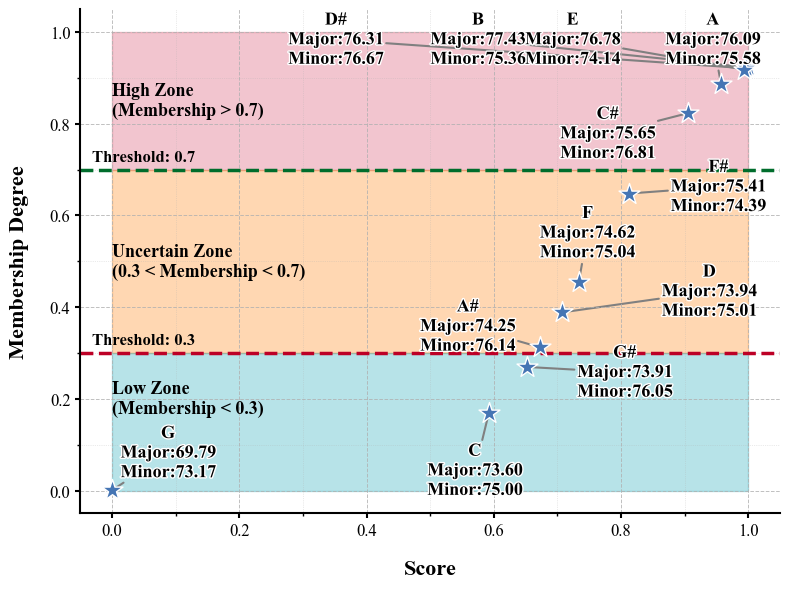

In [15]:
# 创建图形
fig, ax = plt.subplots(figsize=(8, 6))

# 填充区间颜色 (Nature 配色)
ax.fill_between(
    dfsort["TOPSIS_score"], 0.7, 1,
    color='#D64161', alpha=0.3
)
ax.text(
    dfsort["TOPSIS_score"].min(), 0.85, 'High Zone\n(Membership > 0.7)',
    fontsize=13, color='black', weight='bold', va='center'
)

ax.fill_between(
    dfsort["TOPSIS_score"], 0.3, 0.7,
    color='#FF7D00', alpha=0.3
)
ax.text(
    dfsort["TOPSIS_score"].min(), 0.5, 'Uncertain Zone\n(0.3 < Membership < 0.7)',
    fontsize=13, color='black', weight='bold', va='center'
)

ax.fill_between(
    dfsort["TOPSIS_score"], 0, 0.3,
    color='#12A4B6', alpha=0.3
)
ax.text(
    dfsort["TOPSIS_score"].min(), 0.2, 'Low Zone\n(Membership < 0.3)',
    fontsize=13, color='black', weight='bold', va='center'
)

# 绘制散点图，使用星形点
scatter = ax.scatter(
    dfsort["TOPSIS_score"], dfsort["membership"],
    c='#4575b4', s=250, edgecolor='w', zorder=3, marker='*'
)

# 添加事件标注，使用 label 列
texts = [
    ax.text(
        row["TOPSIS_score"], row["membership"], row["label"],
        fontsize=13, weight='bold', color='black',
        path_effects=[withStroke(linewidth=2, foreground="white")]  # 添加白色描边
    ) for _, row in dfsort.iterrows()
]

# 自动调整标注位置
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',  # 简单直线箭头
        color='gray',    # 箭头颜色
        lw=1.5           # 增大箭头线宽
    ),ax=ax,force_text=(1, 1)

)

# 绘制阈值线，并在旁边标注
ax.axhline(y=0.7, color='#006d2c', linestyle='--', linewidth=2.5, zorder=2)
ax.text(
    dfsort["TOPSIS_score"].min() + 0.13, 0.71, 'Threshold: 0.7',
    fontsize=12, color='black', weight='bold', va='bottom', ha='right'
)

ax.axhline(y=0.3, color='#bd0026', linestyle='--', linewidth=2.5, zorder=2)
ax.text(
    dfsort["TOPSIS_score"].min() + 0.13, 0.31, 'Threshold: 0.3',
    fontsize=12, color='black', weight='bold', va='bottom', ha='right'
)

# 设置标题和标签
ax.set_title('', fontsize=16, weight='bold', pad=20)
ax.set_xlabel('Score', fontsize=16, weight='bold', labelpad=15)
ax.set_ylabel('Membership Degree', fontsize=16, weight='bold', labelpad=15)

# 设置坐标轴刻度加粗
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)
ax.tick_params(axis='both', which='minor', labelsize=10, width=1.0)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# 添加网格
ax.grid(visible=True, which='major', linestyle='--', linewidth=0.7, alpha=0.8)
ax.grid(visible=True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

# 去除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调整边框线宽
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# 调整布局
plt.tight_layout()
plt.savefig("音阶排序.svg", bbox_inches='tight', transparent=True)
plt.show()